In [2]:
from pynq import Overlay, MMIO
import pynq.lib as lib
from pynq import allocate
import numpy as np
from pynq.lib import DMA
import time
import matplotlib.pyplot as plt

ol = Overlay("/root/jupyter_notebooks/Filter_1124/iir_1121_wrapper.bit")

In [3]:
ol.ip_dict.keys()

dict_keys(['axi_dma_0', 'zynq_ultra_ps_e_0'])

In [4]:
dma = ol.axi_dma_0
print(f"DMA: {dma}")
print(f"Send channel: {dma.sendchannel}")
print(f"Recv channel: {dma.recvchannel}")

DMA: <pynq.lib.dma.DMA object at 0xffff6e748d90>
Send channel: <pynq.lib.dma._SGDMAChannel object at 0xffffb3e9a710>
Recv channel: <pynq.lib.dma._SGDMAChannel object at 0xffffb3e9a5f0>


In [5]:
# 濾波器參數 (新設計：1:1 輸入輸出)
BLOCK_SIZE = 512

# 測試參數
FS = 30000          # 採樣率 30 kHz
AMPLITUDE = 3000    # 輸入振幅

def calculate_output_size(num_samples):
    """計算給定輸入樣本數的輸出樣本數 (新設計：1:1)"""
    # 新設計：輸入 = 輸出（1:1 比例）
    return num_samples

def pad_to_block_size(num_samples):
    """將樣本數補齊到 512 的倍數"""
    if num_samples % BLOCK_SIZE == 0:
        return num_samples
    return ((num_samples // BLOCK_SIZE) + 1) * BLOCK_SIZE

print(f"Block size: {BLOCK_SIZE}")
print(f"Input/Output ratio: 1:1 (no data loss)")
print(f"Fixed delay: {BLOCK_SIZE} samples")
print(f"\n範例:")
print(f"  512 輸入 → {calculate_output_size(512)} 輸出")
print(f"  1024 輸入 → {calculate_output_size(1024)} 輸出")
print(f"  2048 輸入 → {calculate_output_size(2048)} 輸出")

Block size: 512
Input/Output ratio: 1:1 (no data loss)
Fixed delay: 512 samples

範例:
  512 輸入 → 512 輸出
  1024 輸入 → 1024 輸出
  2048 輸入 → 2048 輸出


In [6]:
def generate_sine(freq, num_samples, fs, amplitude):
    """產生正弦波測試信號"""
    t = np.arange(num_samples) / fs
    return (amplitude * np.sin(2 * np.pi * freq * t)).astype(np.int32)

def reset_dma():
    """重置 DMA channels"""
    dma.sendchannel.stop()
    dma.recvchannel.stop()

def run_filter_test(input_data):
    """
    執行濾波器測試
    
    Parameters:
        input_data: 輸入資料 (長度必須是 512 的倍數)
    
    Returns:
        輸出資料陣列
    """
    num_samples = len(input_data)
    
    # 檢查輸入長度
    if num_samples % BLOCK_SIZE != 0:
        raise ValueError(f"輸入長度 {num_samples} 不是 {BLOCK_SIZE} 的倍數！")
    
    if num_samples < BLOCK_SIZE:
        raise ValueError(f"輸入長度 {num_samples} 必須至少為 {BLOCK_SIZE}！")
    
    # 計算預期輸出數量 (1:1)
    expected_output = calculate_output_size(num_samples)
    
    # 分配 DMA 緩衝區
    input_buffer = allocate(shape=(num_samples,), dtype=np.int32)
    output_buffer = allocate(shape=(expected_output,), dtype=np.int32)
    
    try:
        # 複製輸入資料
        np.copyto(input_buffer, input_data)
        
        # 清空輸出緩衝區
        output_buffer[:] = 0
        
        # 重置 DMA
        reset_dma()
        
        # 啟動 DMA 傳輸
        dma.sendchannel.transfer(input_buffer)
        dma.recvchannel.transfer(output_buffer)
        
        # 等待完成
        dma.sendchannel.wait()
        dma.recvchannel.wait()
        
        # 複製輸出資料
        result = np.array(output_buffer)
        
    finally:
        # 釋放緩衝區
        del input_buffer
        del output_buffer
    
    return result

In [7]:
# 基本測試：1024 個樣本 (需要至少 2 個 block 才有輸出)
print("=" * 50)
print("基本連線測試")
print("=" * 50)

test_samples = 1024  # 2 個 block
test_freq = 50  # Hz

print(f"輸入樣本數: {test_samples}")
print(f"預期輸出樣本數: {calculate_output_size(test_samples)}")

try:
    input_signal = generate_sine(test_freq, test_samples, FS, AMPLITUDE)
    output_signal = run_filter_test(input_signal)
    
    print(f"\n✓ DMA 傳輸成功！")
    print(f"實際輸出樣本數: {len(output_signal)}")
    print(f"輸出範圍: [{output_signal.min()}, {output_signal.max()}]")
    
except Exception as e:
    print(f"\n✗ 錯誤: {e}")

基本連線測試
輸入樣本數: 1024
預期輸出樣本數: 1024

✓ DMA 傳輸成功！
實際輸出樣本數: 1024
輸出範圍: [-2906, 2753]


In [8]:
# 使用更多樣本以獲得更準確的測量
NUM_SAMPLES = 2048  # 4 個 block
freq_test = 50

print(f"輸入樣本數: {NUM_SAMPLES}")
print(f"預期輸出樣本數: {calculate_output_size(NUM_SAMPLES)}")

# 產生測試信號
input_signal = generate_sine(freq_test, NUM_SAMPLES, FS, AMPLITUDE)

# 執行濾波
output_signal = run_filter_test(input_signal)

# 計算增益 (跳過暫態部分)
skip_samples = 600  # 跳過初始暫態
input_max = np.max(np.abs(input_signal[skip_samples:]))
output_max = np.max(np.abs(output_signal[skip_samples:])) if len(output_signal) > skip_samples else np.max(np.abs(output_signal))
gain = output_max / input_max if input_max > 0 else 0

print(f"\n頻率: {freq_test} Hz")
print(f"輸入樣本數: {len(input_signal)}")
print(f"輸出樣本數: {len(output_signal)}")
print(f"輸入振幅: {input_max}")
print(f"輸出振幅: {output_max}")
print(f"增益: {gain:.4f}")
print(f"預期: ~1.0 (通帶)")

輸入樣本數: 2048
預期輸出樣本數: 2048

頻率: 50 Hz
輸入樣本數: 2048
輸出樣本數: 2048
輸入振幅: 3000
輸出振幅: 2895
增益: 0.9650
預期: ~1.0 (通帶)


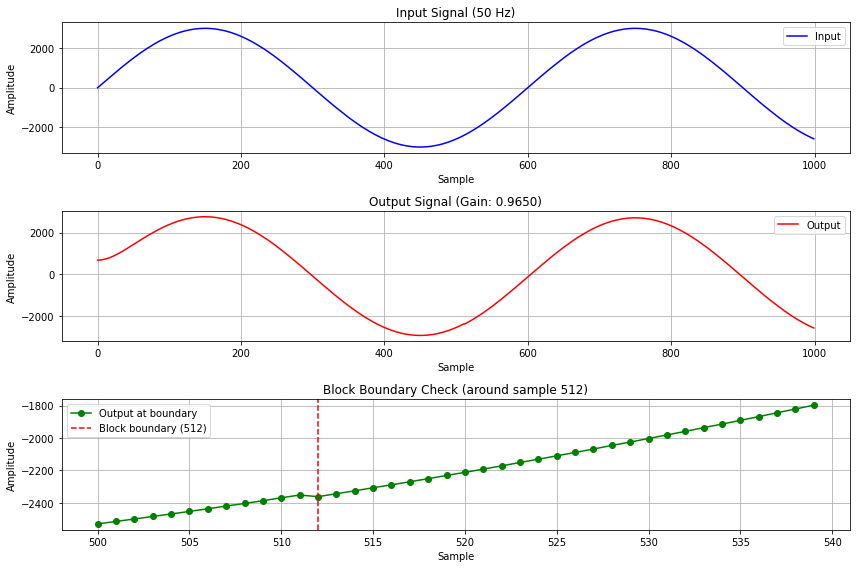

In [106]:
# 繪製波形
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(input_signal[:1000], 'b-', label='Input')
plt.title(f'Input Signal ({freq_test} Hz)')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plot_len = min(1000, len(output_signal))
plt.plot(output_signal[:plot_len], 'r-', label='Output')
plt.title(f'Output Signal (Gain: {gain:.4f})')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

# 邊界檢查圖
plt.subplot(3, 1, 3)
# 顯示 block 邊界附近的波形
boundary_start = 500
boundary_end = 540
if len(output_signal) > boundary_end:
    plt.plot(range(boundary_start, boundary_end), output_signal[boundary_start:boundary_end], 'g-o', label='Output at boundary')
    plt.axvline(x=512, color='r', linestyle='--', label='Block boundary (512)')
    plt.title('Block Boundary Check (around sample 512)')
    plt.xlabel('Sample')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [107]:
# 測試多個頻率
NUM_SAMPLES = 2048  # 使用足夠的樣本數
test_freqs = [1, 10, 50, 100, 200, 300, 500, 1000, 2000]
gains = []

print("頻率響應測試結果:")
print("-" * 50)
print(f"{'頻率 (Hz)':<12} | {'輸出振幅':<12} | {'增益':<10} | {'狀態'}")
print("-" * 50)

for freq in test_freqs:
    # 產生測試信號
    input_signal = generate_sine(freq, NUM_SAMPLES, FS, AMPLITUDE)
    
    # 執行濾波
    output_signal = run_filter_test(input_signal)
    
    # 計算增益 (跳過暫態)
    skip_samples = min(600, len(output_signal) // 2)
    output_max = np.max(np.abs(output_signal[skip_samples:])) if len(output_signal) > skip_samples else 0
    gain = output_max / AMPLITUDE if AMPLITUDE > 0 else 0
    gains.append(gain)
    
    # 判斷狀態
    if freq <= 200:
        status = "PASS" if 0.5 < gain < 1.3 else "WARN"
    elif freq <= 400:
        status = "PASS" if 0.1 < gain < 0.9 else "WARN"
    else:
        status = "PASS" if gain < 0.3 else "WARN"
    
    print(f"{freq:<12} | {output_max:<12.1f} | {gain:<10.4f} | {status}")

print("-" * 50)

頻率響應測試結果:
--------------------------------------------------
頻率 (Hz)      | 輸出振幅         | 增益         | 狀態
--------------------------------------------------
1            | 964.0        | 0.3213     | WARN
10           | 2546.0       | 0.8487     | PASS
50           | 2895.0       | 0.9650     | PASS
100          | 2661.0       | 0.8870     | PASS
200          | 1407.0       | 0.4690     | WARN
300          | 1514.0       | 0.5047     | PASS
500          | 576.0        | 0.1920     | PASS
1000         | 24.0         | 0.0080     | PASS
2000         | 205.0        | 0.0683     | PASS
--------------------------------------------------


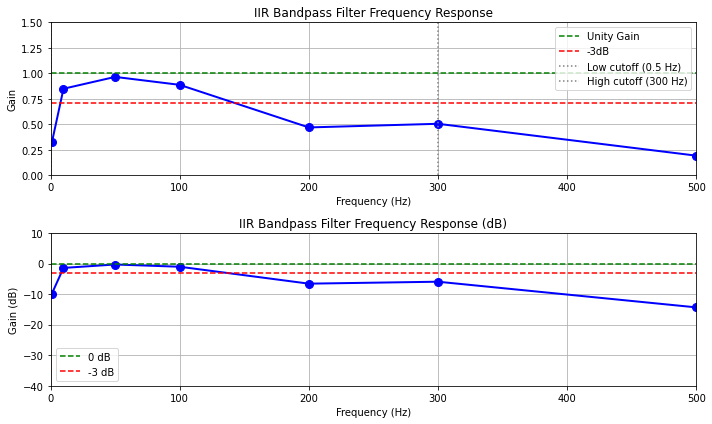

In [110]:
# 繪製頻率響應圖 (線性 x 軸)
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(test_freqs, gains, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=1.0, color='g', linestyle='--', label='Unity Gain')
plt.axhline(y=0.707, color='r', linestyle='--', label='-3dB')
plt.axvline(x=0.5, color='gray', linestyle=':', label='Low cutoff (0.5 Hz)')
plt.axvline(x=300, color='gray', linestyle=':', label='High cutoff (300 Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Gain')
plt.title('IIR Bandpass Filter Frequency Response')
plt.legend()
plt.grid(True)
plt.xlim([0, 500])
plt.ylim([0, 1.5])

plt.subplot(2, 1, 2)
gains_db = 20 * np.log10(np.array(gains) + 1e-10)
plt.plot(test_freqs, gains_db, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=0, color='g', linestyle='--', label='0 dB')
plt.axhline(y=-3, color='r', linestyle='--', label='-3 dB')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Gain (dB)')
plt.title('IIR Bandpass Filter Frequency Response (dB)')
plt.legend()
plt.grid(True)
plt.xlim([0, 500])
plt.ylim([-40, 10])

plt.tight_layout()
plt.show()

In [111]:
# 測試邊界連續性
print("=" * 50)
print("邊界連續性測試")
print("=" * 50)

NUM_SAMPLES = 2048
test_freq = 50

input_signal = generate_sine(test_freq, NUM_SAMPLES, FS, AMPLITUDE)
output_signal = run_filter_test(input_signal)

# 檢查 block 邊界處的連續性
boundary_positions = [511, 512, 1023, 1024, 1535, 1536]

print("\n檢查 block 邊界處的連續性:")
for i in range(0, len(boundary_positions) - 1, 2):
    pos1 = boundary_positions[i]
    pos2 = boundary_positions[i + 1]
    
    if pos2 < len(output_signal):
        val1 = output_signal[pos1]
        val2 = output_signal[pos2]
        diff = abs(val2 - val1)
        avg = (abs(val1) + abs(val2)) / 2
        relative_diff = diff / avg if avg > 10 else diff / 10
        
        status = "OK" if relative_diff < 0.3 else "DISCONTINUITY"
        print(f"  邊界 {pos1}-{pos2}: 值={val1:.1f}, {val2:.1f}, 差異={diff:.1f}, 相對差異={relative_diff:.3f} [{status}]")

邊界連續性測試

檢查 block 邊界處的連續性:
  邊界 511-512: 值=-2352.0, -2362.0, 差異=10.0, 相對差異=0.004 [OK]
  邊界 1023-1024: 值=-2833.0, -2791.0, 差異=42.0, 相對差異=0.015 [OK]
  邊界 1535-1536: 值=-1087.0, -1052.0, 差異=35.0, 相對差異=0.033 [OK]


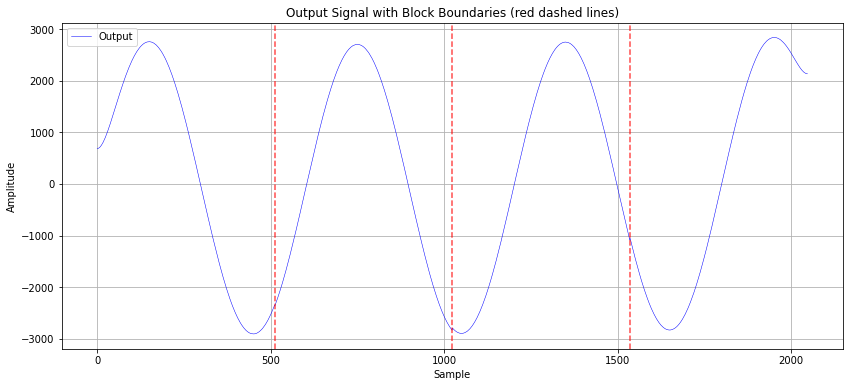

In [112]:
# 繪製完整波形，標記 block 邊界
plt.figure(figsize=(14, 6))

plt.plot(output_signal, 'b-', linewidth=0.5, label='Output')

# 標記 block 邊界
for boundary in [512, 1024, 1536]:
    if boundary < len(output_signal):
        plt.axvline(x=boundary, color='r', linestyle='--', alpha=0.7)

plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.title('Output Signal with Block Boundaries (red dashed lines)')
plt.legend()
plt.grid(True)
plt.show()

大量資料測試:
輸入樣本數: 10240
預期輸出樣本數: 10240

✓ 傳輸成功！
輸入樣本數: 10240
輸出樣本數: 10240
輸入/輸出比: 1.00


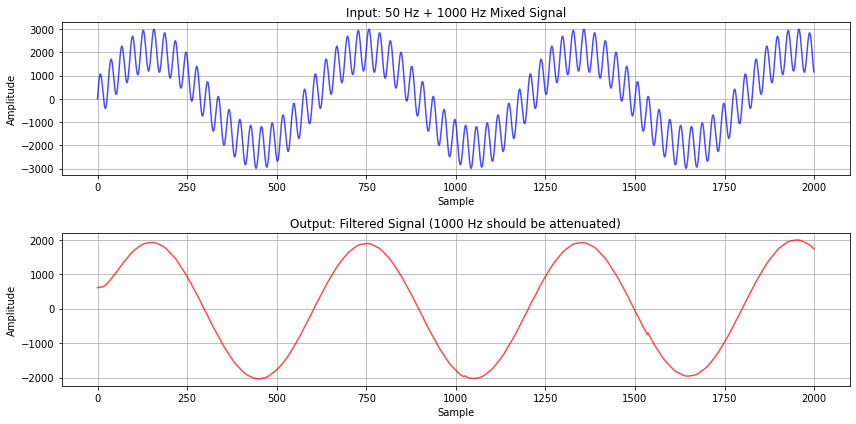

In [113]:
# 測試較大的資料量
LARGE_NUM_SAMPLES = 512 * 20  # 10240 樣本 = 20 個 block

print(f"大量資料測試:")
print(f"輸入樣本數: {LARGE_NUM_SAMPLES}")
print(f"預期輸出樣本數: {calculate_output_size(LARGE_NUM_SAMPLES)}")

# 產生混合頻率信號
t = np.arange(LARGE_NUM_SAMPLES) / FS
# 50 Hz (通帶) + 1000 Hz (阻帶)
mixed_signal = (AMPLITUDE * 0.7 * np.sin(2 * np.pi * 50 * t) + 
                AMPLITUDE * 0.3 * np.sin(2 * np.pi * 1000 * t)).astype(np.int32)

try:
    output_signal = run_filter_test(mixed_signal)
    print(f"\n✓ 傳輸成功！")
    print(f"輸入樣本數: {len(mixed_signal)}")
    print(f"輸出樣本數: {len(output_signal)}")
    print(f"輸入/輸出比: {len(output_signal)/len(mixed_signal):.2f}")
    
    # 繪製結果
    plt.figure(figsize=(12, 6))
    
    plt.subplot(2, 1, 1)
    plt.plot(mixed_signal[:2000], 'b-', alpha=0.7)
    plt.title('Input: 50 Hz + 1000 Hz Mixed Signal')
    plt.xlabel('Sample')
    plt.ylabel('Amplitude')
    plt.grid(True)
    
    plt.subplot(2, 1, 2)
    plt.plot(output_signal[:2000], 'r-', alpha=0.7)
    plt.title('Output: Filtered Signal (1000 Hz should be attenuated)')
    plt.xlabel('Sample')
    plt.ylabel('Amplitude')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"\n✗ 錯誤: {e}")

大量資料測試:
輸入樣本數: 10240
預期輸出樣本數: 10240
✓ 50 Hz (通帶): 輸入/輸出 = 10240/10240, 增益 = 0.9803
✓ 100 Hz (通帶): 輸入/輸出 = 10240/10240, 增益 = 0.8103
✓ 200 Hz (通帶邊緣): 輸入/輸出 = 10240/10240, 增益 = 0.4898
✓ 300 Hz (截止): 輸入/輸出 = 10240/10240, 增益 = 0.5137
✓ 500 Hz (阻帶): 輸入/輸出 = 10240/10240, 增益 = 0.1523
✓ 1000 Hz (阻帶): 輸入/輸出 = 10240/10240, 增益 = 0.0650
✓ 50+1000 Hz (混合): 輸入/輸出 = 10240/10240, 增益 = 0.6885
✓ 10+100+500 Hz (多頻混合): 輸入/輸出 = 10240/10240, 增益 = 0.6740


/tmp/ipykernel_49349/3206838068.py:59: UserWarning: Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49349/3206838068.py:59: UserWarning: Glyph 24118 (\N{CJK UNIFIED IDEOGRAPH-5E36}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49349/3206838068.py:59: UserWarning: Glyph 37002 (\N{CJK UNIFIED IDEOGRAPH-908A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49349/3206838068.py:59: UserWarning: Glyph 32227 (\N{CJK UNIFIED IDEOGRAPH-7DE3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49349/3206838068.py:59: UserWarning: Glyph 25130 (\N{CJK UNIFIED IDEOGRAPH-622A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49349/3206838068.py:59: UserWarning: Glyph 27490 (\N{CJK UNIFIED IDEOGRAPH-6B62}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49349/3206838068.py:59: UserWarning: Glyph 38459 (\N{CJK UNIFIED IDEOGRAP

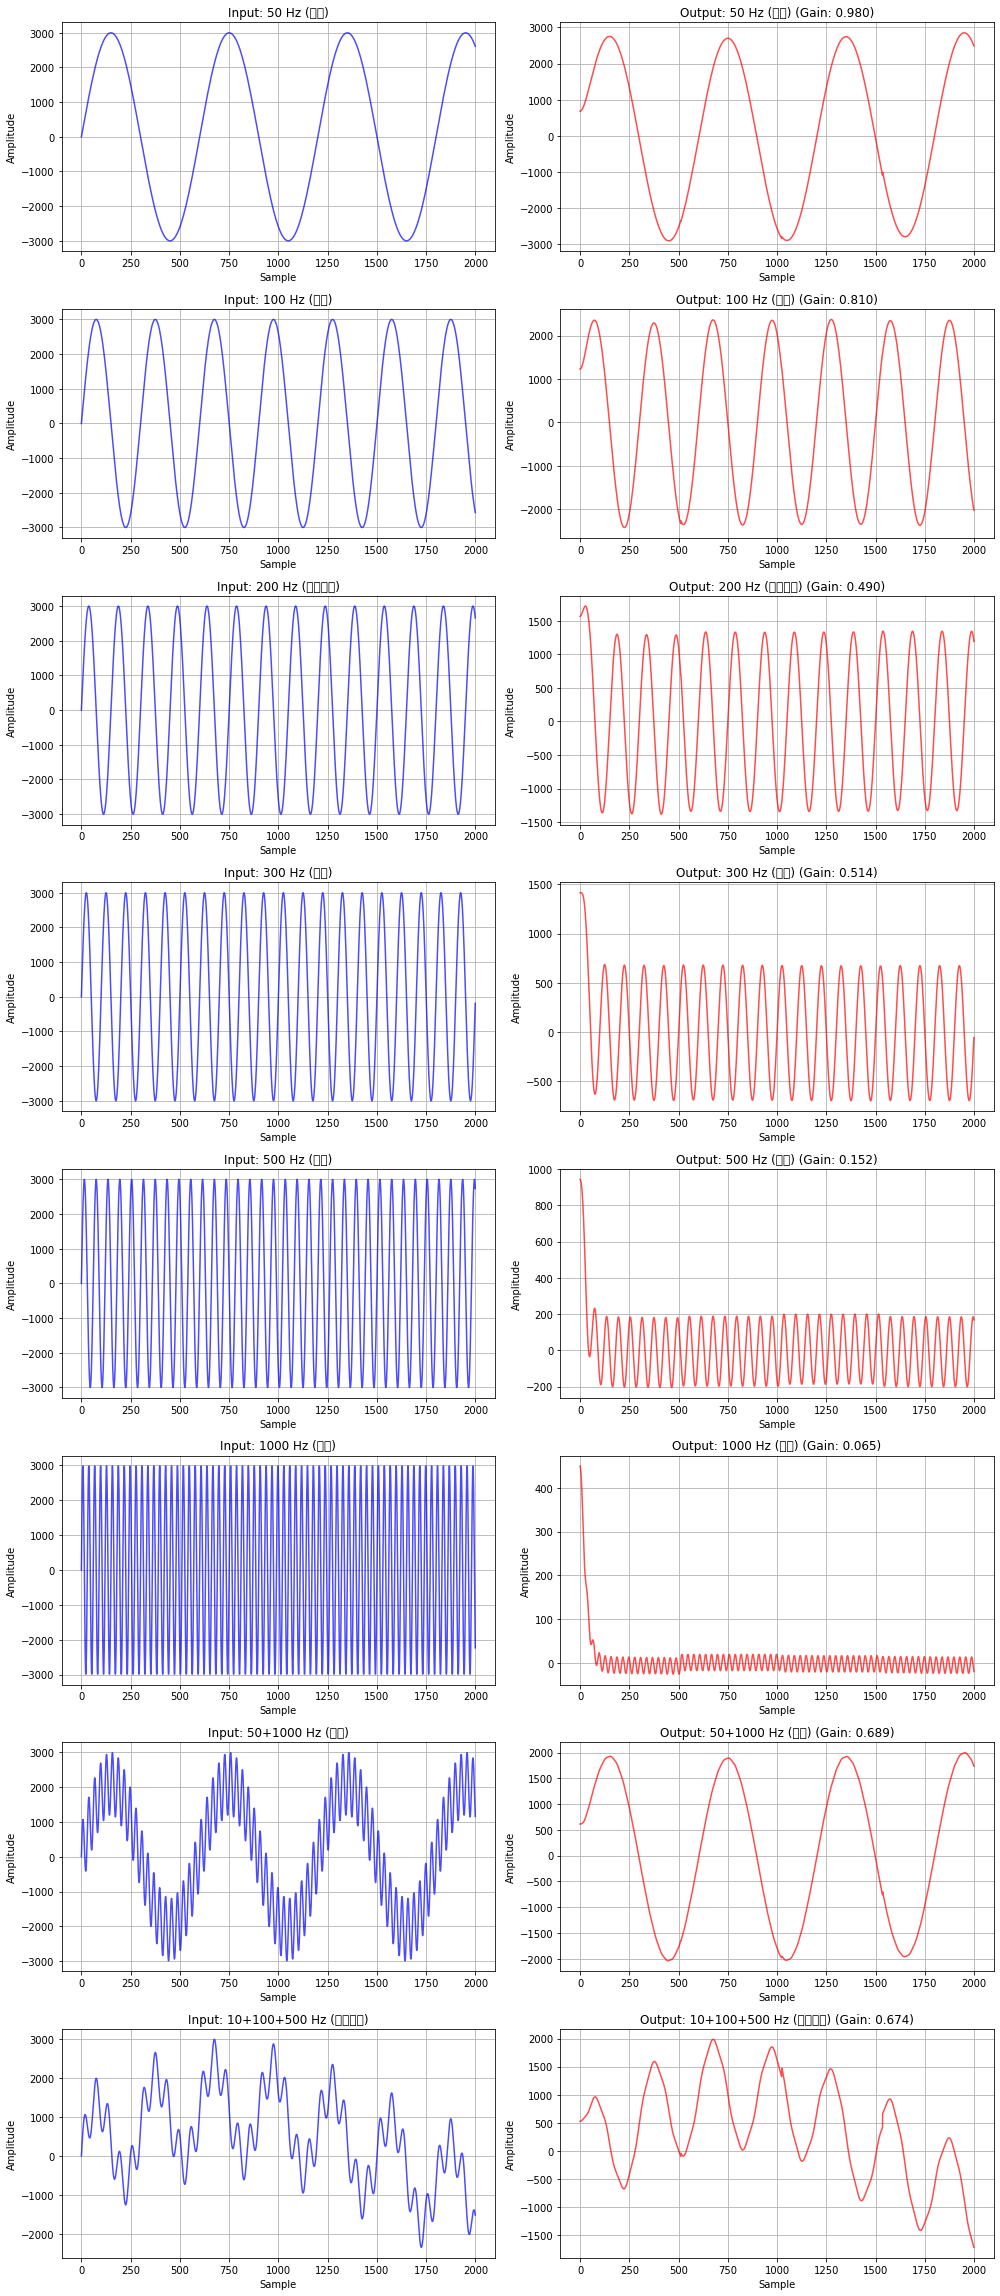

In [114]:
# 測試較大的資料量 - 多頻率測試
LARGE_NUM_SAMPLES = 512 * 20  # 10240 樣本 = 20 個 block

print(f"大量資料測試:")
print(f"輸入樣本數: {LARGE_NUM_SAMPLES}")
print(f"預期輸出樣本數: {calculate_output_size(LARGE_NUM_SAMPLES)}")

# 產生時間軸
t = np.arange(LARGE_NUM_SAMPLES) / FS

# 測試信號列表
test_signals = {
    "50 Hz (通帶)": AMPLITUDE * np.sin(2 * np.pi * 50 * t),
    "100 Hz (通帶)": AMPLITUDE * np.sin(2 * np.pi * 100 * t),
    "200 Hz (通帶邊緣)": AMPLITUDE * np.sin(2 * np.pi * 200 * t),
    "300 Hz (截止)": AMPLITUDE * np.sin(2 * np.pi * 300 * t),
    "500 Hz (阻帶)": AMPLITUDE * np.sin(2 * np.pi * 500 * t),
    "1000 Hz (阻帶)": AMPLITUDE * np.sin(2 * np.pi * 1000 * t),
    "50+1000 Hz (混合)": AMPLITUDE * 0.7 * np.sin(2 * np.pi * 50 * t) + AMPLITUDE * 0.3 * np.sin(2 * np.pi * 1000 * t),
    "10+100+500 Hz (多頻混合)": AMPLITUDE * 0.4 * np.sin(2 * np.pi * 10 * t) + AMPLITUDE * 0.4 * np.sin(2 * np.pi * 100 * t) + AMPLITUDE * 0.2 * np.sin(2 * np.pi * 500 * t),
}

# 繪製所有測試結果
fig, axes = plt.subplots(len(test_signals), 2, figsize=(14, 4 * len(test_signals)))

for idx, (name, signal) in enumerate(test_signals.items()):
    input_signal = signal.astype(np.int32)
    
    try:
        output_signal = run_filter_test(input_signal)
        
        # 計算增益
        skip = 600
        input_max = np.max(np.abs(input_signal[skip:]))
        output_max = np.max(np.abs(output_signal[skip:])) if len(output_signal) > skip else np.max(np.abs(output_signal))
        gain = output_max / input_max if input_max > 0 else 0
        
        # 繪製輸入
        axes[idx, 0].plot(input_signal[:2000], 'b-', alpha=0.7)
        axes[idx, 0].set_title(f'Input: {name}')
        axes[idx, 0].set_xlabel('Sample')
        axes[idx, 0].set_ylabel('Amplitude')
        axes[idx, 0].grid(True)
        
        # 繪製輸出
        axes[idx, 1].plot(output_signal[:2000], 'r-', alpha=0.7)
        axes[idx, 1].set_title(f'Output: {name} (Gain: {gain:.3f})')
        axes[idx, 1].set_xlabel('Sample')
        axes[idx, 1].set_ylabel('Amplitude')
        axes[idx, 1].grid(True)
        
        print(f"✓ {name}: 輸入/輸出 = {len(input_signal)}/{len(output_signal)}, 增益 = {gain:.4f}")
        
    except Exception as e:
        print(f"✗ {name}: 錯誤 - {e}")
        axes[idx, 0].text(0.5, 0.5, f'Error: {e}', ha='center', va='center')
        axes[idx, 1].text(0.5, 0.5, f'Error: {e}', ha='center', va='center')

plt.tight_layout()
plt.show()

In [128]:
# Noise removal test
# Test scenario: passband signal + high-frequency noise (>500Hz), filter should preserve passband and remove noise
import time

print("=" * 50)
print("Noise Removal Test")
print("=" * 50)

NOISE_TEST_SAMPLES = 512 * 100  # 10240 samples = 20 blocks

# Generate time axis
t = np.arange(NOISE_TEST_SAMPLES) / FS

# 1. Generate original clean signal (multi-frequency signal in passband)
clean_signal_50Hz = AMPLITUDE * 0.5 * np.sin(2 * np.pi * 50 * t)
clean_signal_100Hz = AMPLITUDE * 0.3 * np.sin(2 * np.pi * 100 * t)
clean_signal_200Hz = AMPLITUDE * 0.2 * np.sin(2 * np.pi * 200 * t)
clean_signal = clean_signal_50Hz + clean_signal_100Hz + clean_signal_200Hz

# 2. Generate high-frequency random noise (>500Hz)
# Method: Generate random amplitude modulation for multiple high frequencies
np.random.seed(42)  # Set seed for reproducibility
noise_amplitude = AMPLITUDE * 1.0  # Adjust noise level

# Generate noise by summing random-amplitude sine waves at high frequencies
num_noise_freqs = 50  # Number of frequency components
noise_freqs = np.linspace(500, 15000, num_noise_freqs)  # Frequencies from 500Hz to 15kHz
random_noise = np.zeros(NOISE_TEST_SAMPLES)

# Create random amplitude for each frequency component
random_amplitudes = noise_amplitude * np.random.randn(num_noise_freqs) / np.sqrt(num_noise_freqs)
random_phases = 2 * np.pi * np.random.rand(num_noise_freqs)

for i, freq in enumerate(noise_freqs):
    random_noise += random_amplitudes[i] * np.sin(2 * np.pi * freq * t + random_phases[i])

# 3. Generate noisy signal
noisy_signal = clean_signal + random_noise

# Convert to int32
clean_signal_int = clean_signal.astype(np.int32)
noisy_signal_int = noisy_signal.astype(np.int32)

# 4. Filter both clean and noisy signals with timing
print("\nFiltering clean signal...")
start_time_clean = time.time()
filtered_clean = run_filter_test(clean_signal_int)
end_time_clean = time.time()
processing_time_clean = (end_time_clean - start_time_clean) * 1000  # Convert to ms

print("Filtering noisy signal...")
start_time_noisy = time.time()
filtered_noisy = run_filter_test(noisy_signal_int)
end_time_noisy = time.time()
processing_time_noisy = (end_time_noisy - start_time_noisy) * 1000  # Convert to ms

# 5. Calculate signal statistics
skip = 600  # Skip transient
clean_rms = np.sqrt(np.mean(clean_signal_int[skip:]**2))
noisy_rms = np.sqrt(np.mean(noisy_signal_int[skip:]**2))
filtered_noisy_rms = np.sqrt(np.mean(filtered_noisy[skip:]**2))
filtered_clean_rms = np.sqrt(np.mean(filtered_clean[skip:]**2))

# Calculate SNR (Signal to Noise Ratio)
noise_power = np.mean((noisy_signal_int[skip:] - clean_signal_int[skip:])**2)
signal_power = np.mean(clean_signal_int[skip:]**2)
input_snr = 10 * np.log10(signal_power / noise_power) if noise_power > 0 else float('inf')

# Output SNR after filtering (compared to clean signal)
filtered_noise = filtered_noisy[skip:].astype(np.float64) - filtered_clean[skip:].astype(np.float64)
output_noise_power = np.mean(filtered_noise**2)
output_signal_power = np.mean(filtered_clean[skip:].astype(np.float64)**2)
output_snr = 10 * np.log10(output_signal_power / output_noise_power) if output_noise_power > 0 else float('inf')

# Calculate processing statistics
avg_processing_time = (processing_time_clean + processing_time_noisy) / 2
signal_duration = NOISE_TEST_SAMPLES / FS * 1000  # Convert to ms
real_time_factor = signal_duration / avg_processing_time if avg_processing_time > 0 else 0
throughput = NOISE_TEST_SAMPLES / (avg_processing_time / 1000) if avg_processing_time > 0 else 0  # samples/sec

print(f"\nStatistics:")
print(f"  Clean signal RMS: {clean_rms:.1f}")
print(f"  Noisy signal RMS: {noisy_rms:.1f}")
print(f"  Filtered (clean) RMS: {filtered_clean_rms:.1f}")
print(f"  Filtered (noisy) RMS: {filtered_noisy_rms:.1f}")
print(f"\nSNR:")
print(f"  Input SNR: {input_snr:.2f} dB")
print(f"  Output SNR: {output_snr:.2f} dB")
print(f"  SNR improvement: {output_snr - input_snr:.2f} dB")

# Calculate noise suppression
noise_before = np.sqrt(noise_power)
noise_after = np.sqrt(output_noise_power)
noise_reduction = 20 * np.log10(noise_before / noise_after) if noise_after > 0 else float('inf')
print(f"  Noise suppression: {noise_reduction:.2f} dB")

print(f"\nNoise characteristics:")
print(f"  Frequency range: 500 Hz - 15 kHz")
print(f"  Number of frequency components: {num_noise_freqs}")

print(f"\nProcessing Performance:")
print(f"  Number of samples: {NOISE_TEST_SAMPLES}")
print(f"  Signal duration: {signal_duration:.2f} ms")
print(f"  Processing time (clean): {processing_time_clean:.2f} ms")
print(f"  Processing time (noisy): {processing_time_noisy:.2f} ms")
print(f"  Average processing time: {avg_processing_time:.2f} ms")
# print(f"  Real-time factor: {real_time_factor:.2f}x (>1 means faster than real-time)")
print(f"  Throughput: {throughput:.0f} samples/sec ({throughput/1000:.1f} kSPS)")

Noise Removal Test

Filtering clean signal...
Filtering noisy signal...

Statistics:
  Clean signal RMS: 1308.3
  Noisy signal RMS: 2407.7
  Filtered (clean) RMS: 1127.3
  Filtered (noisy) RMS: 1127.8

SNR:
  Input SNR: -3.78 dB
  Output SNR: 38.89 dB
  SNR improvement: 42.66 dB
  Noise suppression: 43.96 dB

Noise characteristics:
  Frequency range: 500 Hz - 15 kHz
  Number of frequency components: 50

Processing Performance:
  Number of samples: 51200
  Signal duration: 1706.67 ms
  Processing time (clean): 25.95 ms
  Processing time (noisy): 23.66 ms
  Average processing time: 24.80 ms
  Throughput: 2064233 samples/sec (2064.2 kSPS)


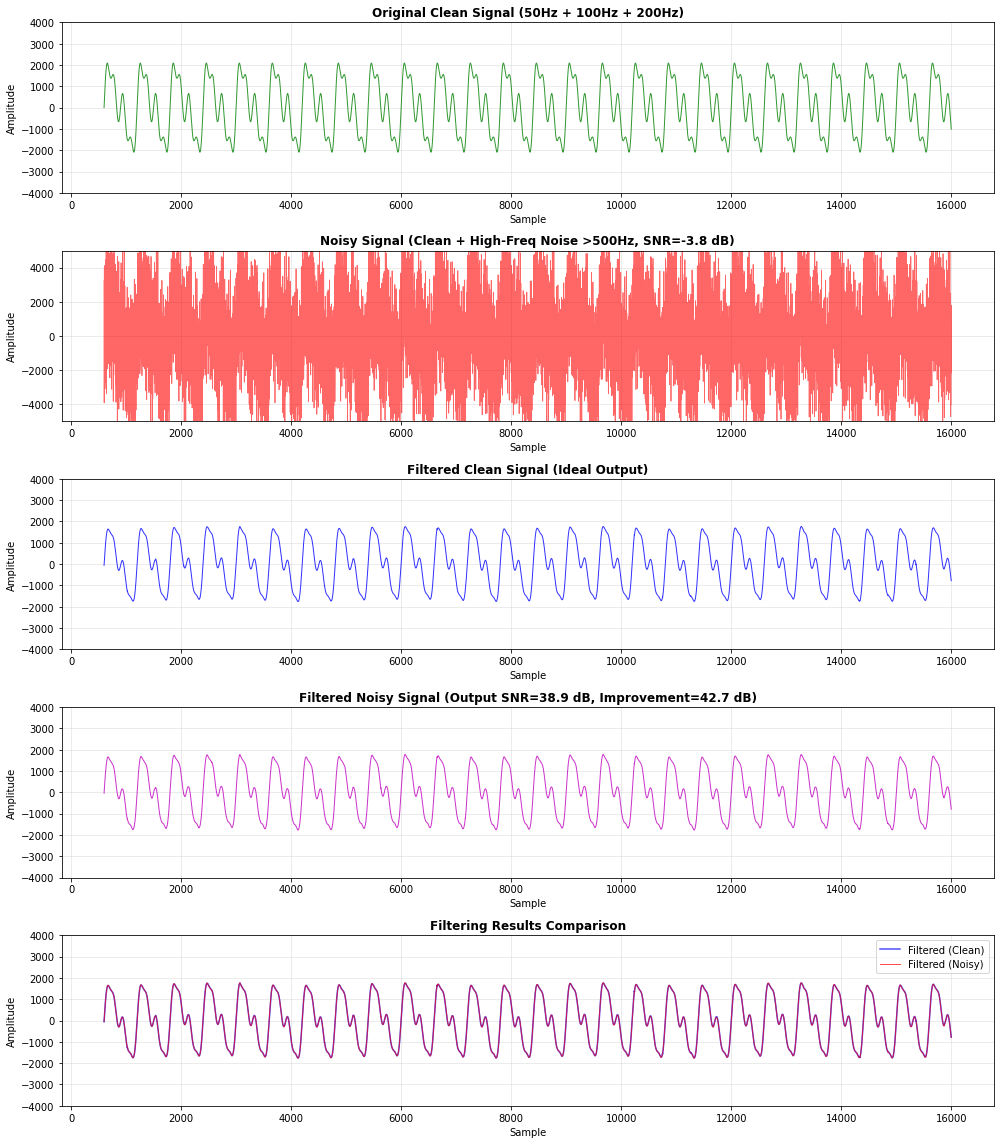


Test Conclusion:
✓ Filter successfully removed high-frequency noise!
  - SNR improved by 42.7 dB
  - Noise suppression: 44.0 dB


In [124]:
# Plot noise removal comparison
fig, axes = plt.subplots(5, 1, figsize=(14, 16))

# Display range
plot_start = 600
plot_end = 16000

# 1. Original clean signal
axes[0].plot(range(plot_start, plot_end), clean_signal_int[plot_start:plot_end], 'g-', alpha=0.8, linewidth=1)
axes[0].set_title('Original Clean Signal (50Hz + 100Hz + 200Hz)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([-4000, 4000])

# 2. Noisy signal
axes[1].plot(range(plot_start, plot_end), noisy_signal_int[plot_start:plot_end], 'r-', alpha=0.6, linewidth=0.8)
axes[1].set_title(f'Noisy Signal (Clean + High-Freq Noise >500Hz, SNR={input_snr:.1f} dB)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([-5000, 5000])

# 3. Filtered clean signal (reference)
axes[2].plot(range(plot_start, plot_end), filtered_clean[plot_start:plot_end], 'b-', alpha=0.8, linewidth=1)
axes[2].set_title('Filtered Clean Signal (Ideal Output)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Sample')
axes[2].set_ylabel('Amplitude')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([-4000, 4000])

# 4. Filtered noisy signal
axes[3].plot(range(plot_start, plot_end), filtered_noisy[plot_start:plot_end], 'm-', alpha=0.8, linewidth=1)
axes[3].set_title(f'Filtered Noisy Signal (Output SNR={output_snr:.1f} dB, Improvement={output_snr-input_snr:.1f} dB)', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Sample')
axes[3].set_ylabel('Amplitude')
axes[3].grid(True, alpha=0.3)
axes[3].set_ylim([-4000, 4000])

# 5. Comparison: overlay filtered clean and noisy signals
axes[4].plot(range(plot_start, plot_end), filtered_clean[plot_start:plot_end], 'b-', alpha=0.7, linewidth=1.5, label='Filtered (Clean)')
axes[4].plot(range(plot_start, plot_end), filtered_noisy[plot_start:plot_end], 'r-', alpha=0.7, linewidth=1, label='Filtered (Noisy)')
axes[4].set_title('Filtering Results Comparison', fontsize=12, fontweight='bold')
axes[4].set_xlabel('Sample')
axes[4].set_ylabel('Amplitude')
axes[4].legend(loc='upper right')
axes[4].grid(True, alpha=0.3)
axes[4].set_ylim([-4000, 4000])

plt.tight_layout()
plt.show()

# Test conclusion
print("\n" + "=" * 50)
print("Test Conclusion:")
print("=" * 50)
if output_snr - input_snr > 10:
    print(f"✓ Filter successfully removed high-frequency noise!")
    print(f"  - SNR improved by {output_snr - input_snr:.1f} dB")
    print(f"  - Noise suppression: {noise_reduction:.1f} dB")
elif output_snr - input_snr > 5:
    print(f"⚠ Filter partially removed noise")
    print(f"  - SNR improved by {output_snr - input_snr:.1f} dB")
else:
    print(f"✗ Filtering effect is poor")
    print(f"  - SNR only improved by {output_snr - input_snr:.1f} dB")

In [10]:
# Load and test real signal from .npy file
import time

# Path to your .npy file (modify this path)
NPY_FILE_PATH = "/root/jupyter_notebooks/Filter_1124/lfp_data_2s_lfp_data_2s_int32.npy"

print("=" * 50)
print("Real Signal Test from .npy File")
print("=" * 50)

try:
    # Load the .npy file
    print(f"\nLoading signal from: {NPY_FILE_PATH}")
    real_signal = np.load(NPY_FILE_PATH)
    
    # Flatten to 1D array if needed
    if real_signal.ndim > 1:
        print(f"  Original shape: {real_signal.shape}")
        real_signal = real_signal.flatten()
        print(f"  Flattened to 1D: {real_signal.shape}")
    
    # Verify data
    print(f"\nSignal Information:")
    print(f"  Data type: {real_signal.dtype}")
    print(f"  Shape: {real_signal.shape}")
    print(f"  Length: {len(real_signal)}")
    print(f"  Min value: {real_signal.min()}")
    print(f"  Max value: {real_signal.max()}")
    print(f"  Mean: {real_signal.mean():.2f}")
    print(f"  Std: {real_signal.std():.2f}")
    
    # Check if length is multiple of 512
    if len(real_signal) % BLOCK_SIZE != 0:
        print(f"\n⚠ Warning: Signal length {len(real_signal)} is not a multiple of {BLOCK_SIZE}")
        print(f"  Padding to nearest multiple...")
        pad_length = BLOCK_SIZE - (len(real_signal) % BLOCK_SIZE)
        real_signal = np.pad(real_signal, (0, pad_length), mode='constant', constant_values=0)
        print(f"  New length: {len(real_signal)}")
    else:
        print(f"\n✓ Signal length is valid (multiple of {BLOCK_SIZE})")
    
    # Ensure data type is int32
    if real_signal.dtype != np.int32:
        print(f"\n⚠ Converting from {real_signal.dtype} to int32...")
        real_signal = real_signal.astype(np.int32)
    
    # Run filter test with timing
    print(f"\nFiltering real signal...")
    start_time = time.time()
    filtered_signal = run_filter_test(real_signal)
    end_time = time.time()
    processing_time = (end_time - start_time) * 1000  # ms
    
    # Calculate performance metrics
    signal_duration = len(real_signal) / FS * 1000  # ms
    real_time_factor = signal_duration / processing_time if processing_time > 0 else 0
    throughput = len(real_signal) / (processing_time / 1000) if processing_time > 0 else 0
    
    print(f"\n✓ Filtering completed!")
    print(f"\nOutput Information:")
    print(f"  Output length: {len(filtered_signal)}")
    print(f"  Output min: {filtered_signal.min()}")
    print(f"  Output max: {filtered_signal.max()}")
    print(f"  Output mean: {filtered_signal.mean():.2f}")
    print(f"  Output std: {filtered_signal.std():.2f}")
    
    print(f"\nPerformance:")
    print(f"  Input samples: {len(real_signal)}")
    print(f"  Signal duration: {signal_duration:.2f} ms")
    print(f"  Processing time: {processing_time:.2f} ms")
    print(f"  Real-time factor: {real_time_factor:.2f}x")
    print(f"  Throughput: {throughput:.0f} samples/sec ({throughput/1000:.1f} kSPS)")
    
    # Save filtered output
    output_path = NPY_FILE_PATH.replace('.npy', '_filtered.npy')
    np.save(output_path, filtered_signal)
    print(f"\n✓ Filtered signal saved to: {output_path}")
    
except FileNotFoundError:
    print(f"\n✗ Error: File not found: {NPY_FILE_PATH}")
    print(f"  Please upload your .npy file to the PYNQ board first.")
except Exception as e:
    print(f"\n✗ Error: {e}")

Real Signal Test from .npy File

Loading signal from: /root/jupyter_notebooks/Filter_1124/lfp_data_2s_lfp_data_2s_int32.npy

Signal Information:
  Data type: int32
  Shape: (60416,)
  Length: 60416
  Min value: -328
  Max value: 458
  Mean: 16.13
  Std: 121.59

✓ Signal length is valid (multiple of 512)

Filtering real signal...

✓ Filtering completed!

Output Information:
  Output length: 60416
  Output min: -193
  Output max: 376
  Output mean: 11.91
  Output std: 98.12

Performance:
  Input samples: 60416
  Signal duration: 2013.87 ms
  Processing time: 27.64 ms
  Real-time factor: 72.86x
  Throughput: 2185809 samples/sec (2185.8 kSPS)

✓ Filtered signal saved to: /root/jupyter_notebooks/Filter_1124/lfp_data_2s_lfp_data_2s_int32_filtered.npy



Signal Comparison Visualization


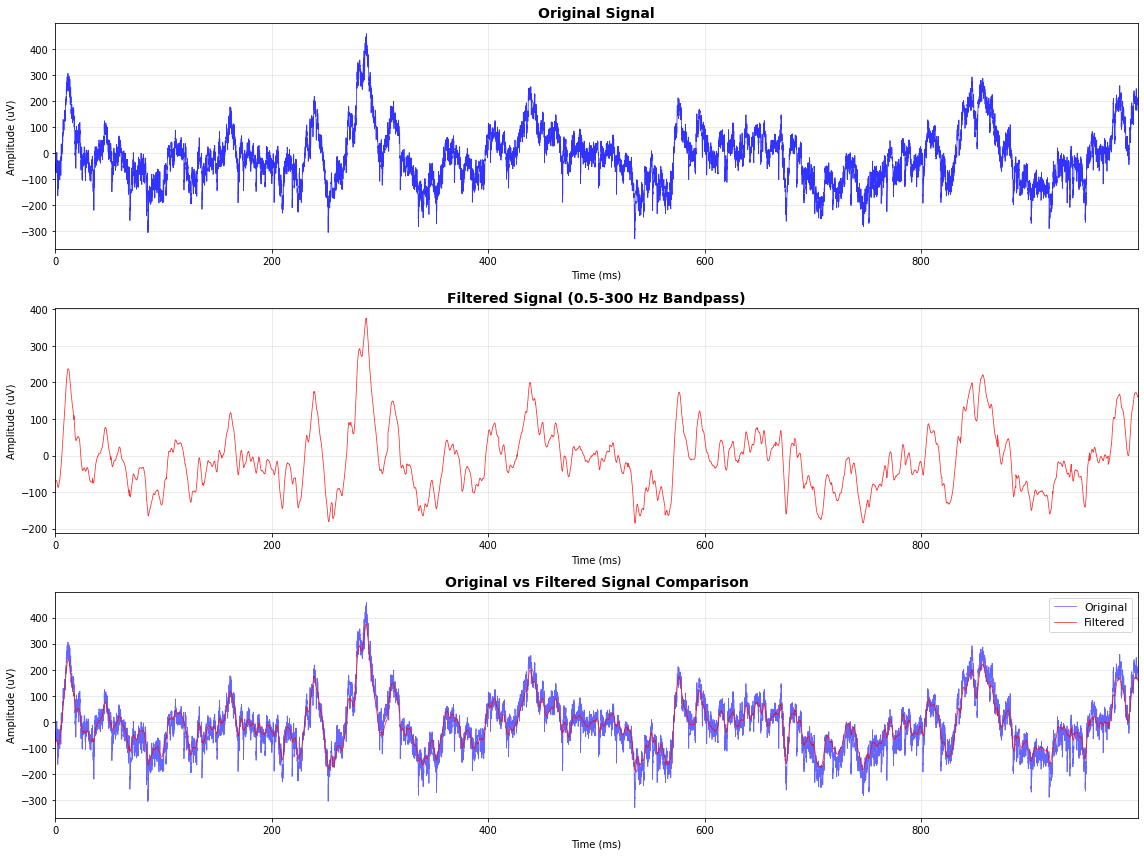


Showing zoomed view (first 500 samples)...


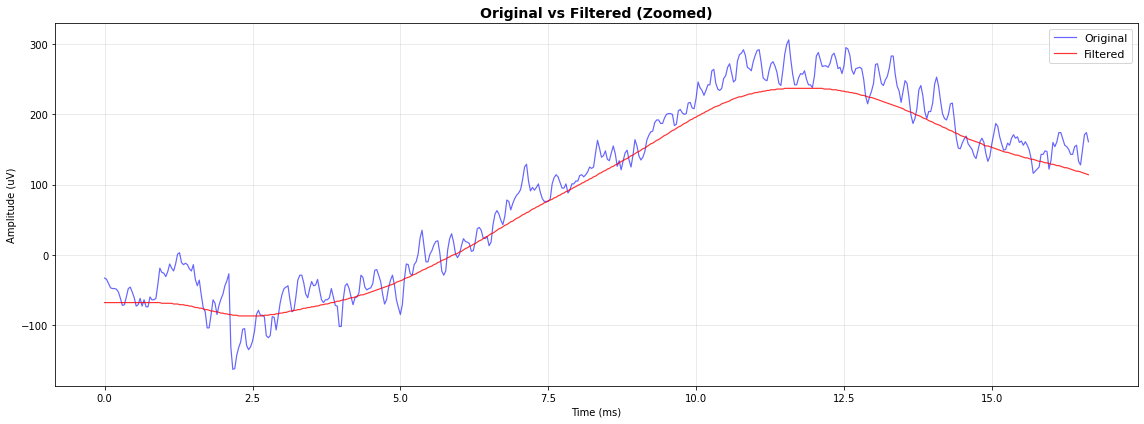


✓ Visualization completed!


In [11]:
# Visualize original vs filtered signal comparison
print("\n" + "=" * 50)
print("Signal Comparison Visualization")
print("=" * 50)

# Calculate display parameters
plot_samples = min(30000, len(real_signal))
plot_time = np.arange(plot_samples) / FS * 1000  # ms

# Create comparison plots
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# 1. Original signal
axes[0].plot(plot_time, real_signal[:plot_samples], 'b-', linewidth=0.8, alpha=0.8)
axes[0].set_title('Original Signal', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Amplitude (uV)')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, plot_time[-1]])

# 2. Filtered signal
axes[1].plot(plot_time, filtered_signal[:plot_samples], 'r-', linewidth=0.8, alpha=0.8)
axes[1].set_title('Filtered Signal (0.5-300 Hz Bandpass)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Amplitude (uV)')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, plot_time[-1]])

# 3. Overlay comparison
axes[2].plot(plot_time, real_signal[:plot_samples], 'b-', linewidth=0.8, alpha=0.6, label='Original')
axes[2].plot(plot_time, filtered_signal[:plot_samples], 'r-', linewidth=0.8, alpha=0.8, label='Filtered')
axes[2].set_title('Original vs Filtered Signal Comparison', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Time (ms)')
axes[2].set_ylabel('Amplitude (uV)')
axes[2].legend(loc='upper right', fontsize=11)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim([0, plot_time[-1]])

plt.tight_layout()
plt.show()

# Show zoomed view
print("\nShowing zoomed view (first 500 samples)...")

zoom_samples = min(500, len(real_signal))
zoom_time = np.arange(zoom_samples) / FS * 1000

fig, ax = plt.subplots(1, 1, figsize=(16, 6))
ax.plot(zoom_time, real_signal[:zoom_samples], 'b-', linewidth=1.2, alpha=0.6, label='Original')
ax.plot(zoom_time, filtered_signal[:zoom_samples], 'r-', linewidth=1.2, alpha=0.8, label='Filtered')
ax.set_title('Original vs Filtered (Zoomed)', fontsize=14, fontweight='bold')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude (uV)')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Visualization completed!")

Power Spectral Density (PSD) Analysis

PSD Configuration:
  Window length: 30000 samples (1.0 sec)
  Overlap: 15000 samples (50%)
  NFFT: 30000
  Frequency resolution: 1.000 Hz

Calculating PSD for original signal...
Calculating PSD for filtered signal...

✓ PSD calculation completed!
  Frequency range: 0.00 - 500.00 Hz
  Number of frequency bins: 501

Power in 0-500 Hz band:
  Original signal: 1.30e+04 uV^2
  Filtered signal: 8.82e+03 uV^2
  Power ratio (Filtered/Original): 0.6784


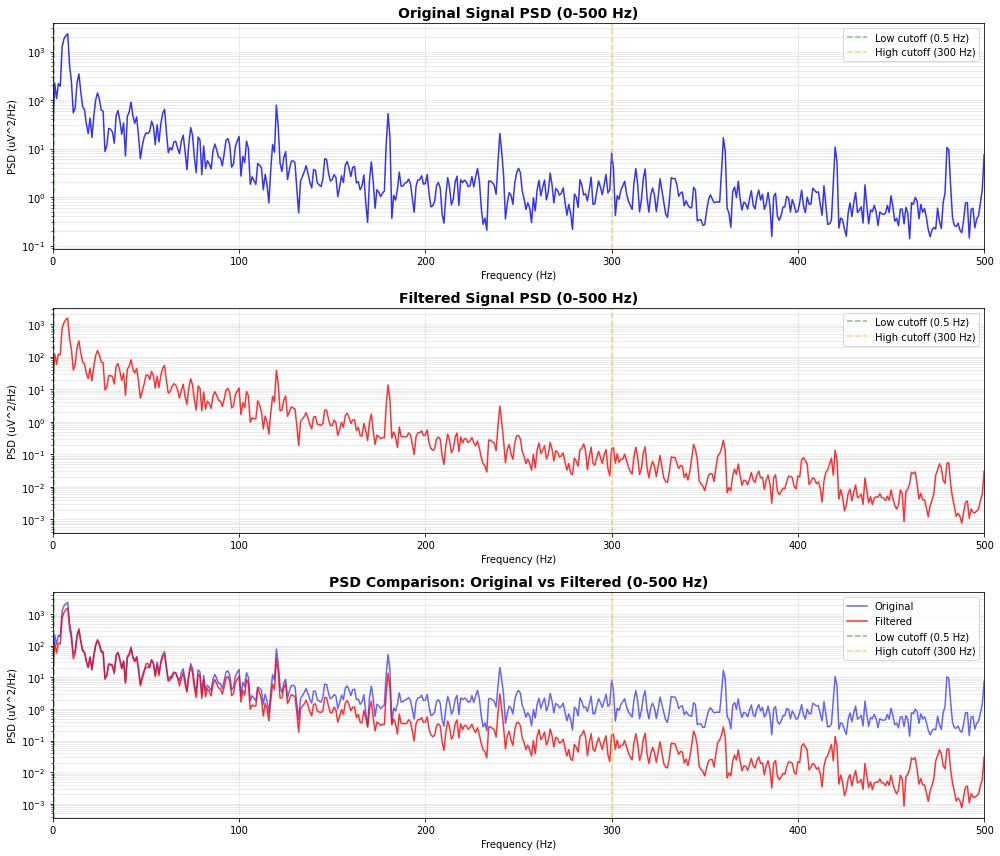


Frequency Band Power Analysis

Band                           | Original        | Filtered        | Ratio     
---------------------------------------------------------------------------
Delta (0.5-4 Hz)               | 5.34e+02        | 2.98e+02        | 0.5570    
Theta (4-8 Hz)                 | 6.47e+03        | 4.09e+03        | 0.6326    
Alpha (8-13 Hz)                | 2.17e+03        | 1.50e+03        | 0.6900    
Beta (13-30 Hz)                | 1.40e+03        | 1.38e+03        | 0.9856    
Gamma (30-100 Hz)              | 1.40e+03        | 1.24e+03        | 0.8867    
High Gamma (100-300 Hz)        | 6.67e+02        | 2.32e+02        | 0.3486    
Above Filter (300-500 Hz)      | 2.31e+02        | 6.11e+00        | 0.0264    

✓ PSD analysis completed!


In [13]:
# Calculate Power Spectral Density (PSD) for 0-500 Hz
from scipy import signal as sp_signal

print("=" * 50)
print("Power Spectral Density (PSD) Analysis")
print("=" * 50)

# PSD parameters
WINDOW_LENGTH = int(FS * 1.0)  # 1 second window = 30000 samples
OVERLAP = int(WINDOW_LENGTH * 0.5)  # 50% overlap = 15000 samples
NFFT = WINDOW_LENGTH  # FFT points = window length

print(f"\nPSD Configuration:")
print(f"  Window length: {WINDOW_LENGTH} samples ({WINDOW_LENGTH/FS:.1f} sec)")
print(f"  Overlap: {OVERLAP} samples ({OVERLAP/WINDOW_LENGTH*100:.0f}%)")
print(f"  NFFT: {NFFT}")
print(f"  Frequency resolution: {FS/NFFT:.3f} Hz")

# Calculate PSD for original signal
print(f"\nCalculating PSD for original signal...")
freqs_orig, psd_orig = sp_signal.welch(
    real_signal,
    fs=FS,
    window='hann',
    nperseg=WINDOW_LENGTH,
    noverlap=OVERLAP,
    nfft=NFFT,
    scaling='density',
    detrend='constant'
)

# Calculate PSD for filtered signal
print(f"Calculating PSD for filtered signal...")
freqs_filt, psd_filt = sp_signal.welch(
    filtered_signal,
    fs=FS,
    window='hann',
    nperseg=WINDOW_LENGTH,
    noverlap=OVERLAP,
    nfft=NFFT,
    scaling='density',
    detrend='constant'
)

# Limit to 0-500 Hz
freq_mask = (freqs_orig >= 0) & (freqs_orig <= 500)
freqs_orig_limited = freqs_orig[freq_mask]
psd_orig_limited = psd_orig[freq_mask]
psd_filt_limited = psd_filt[freq_mask]

print(f"\n✓ PSD calculation completed!")
print(f"  Frequency range: {freqs_orig_limited[0]:.2f} - {freqs_orig_limited[-1]:.2f} Hz")
print(f"  Number of frequency bins: {len(freqs_orig_limited)}")

# Calculate total power in 0-500 Hz band
power_orig = np.trapz(psd_orig_limited, freqs_orig_limited)
power_filt = np.trapz(psd_filt_limited, freqs_orig_limited)
power_ratio = power_filt / power_orig if power_orig > 0 else 0

print(f"\nPower in 0-500 Hz band:")
print(f"  Original signal: {power_orig:.2e} uV^2")
print(f"  Filtered signal: {power_filt:.2e} uV^2")
print(f"  Power ratio (Filtered/Original): {power_ratio:.4f}")

# Plot PSD comparison
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. Original signal PSD
axes[0].semilogy(freqs_orig_limited, psd_orig_limited, 'b-', linewidth=1.5, alpha=0.8)
axes[0].axvline(x=0.5, color='g', linestyle='--', linewidth=1.5, alpha=0.5, label='Low cutoff (0.5 Hz)')
axes[0].axvline(x=300, color='orange', linestyle='--', linewidth=1.5, alpha=0.5, label='High cutoff (300 Hz)')
axes[0].set_title('Original Signal PSD (0-500 Hz)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('PSD (uV^2/Hz)')
axes[0].grid(True, alpha=0.3, which='both')
axes[0].legend(loc='upper right', fontsize=10)
axes[0].set_xlim([0, 500])

# 2. Filtered signal PSD
axes[1].semilogy(freqs_orig_limited, psd_filt_limited, 'r-', linewidth=1.5, alpha=0.8)
axes[1].axvline(x=0.5, color='g', linestyle='--', linewidth=1.5, alpha=0.5, label='Low cutoff (0.5 Hz)')
axes[1].axvline(x=300, color='orange', linestyle='--', linewidth=1.5, alpha=0.5, label='High cutoff (300 Hz)')
axes[1].set_title('Filtered Signal PSD (0-500 Hz)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('PSD (uV^2/Hz)')
axes[1].grid(True, alpha=0.3, which='both')
axes[1].legend(loc='upper right', fontsize=10)
axes[1].set_xlim([0, 500])

# 3. PSD comparison overlay
axes[2].semilogy(freqs_orig_limited, psd_orig_limited, 'b-', linewidth=1.5, alpha=0.6, label='Original')
axes[2].semilogy(freqs_orig_limited, psd_filt_limited, 'r-', linewidth=1.5, alpha=0.8, label='Filtered')
axes[2].axvline(x=0.5, color='g', linestyle='--', linewidth=1.5, alpha=0.5, label='Low cutoff (0.5 Hz)')
axes[2].axvline(x=300, color='orange', linestyle='--', linewidth=1.5, alpha=0.5, label='High cutoff (300 Hz)')
axes[2].set_title('PSD Comparison: Original vs Filtered (0-500 Hz)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('PSD (uV^2/Hz)')
axes[2].grid(True, alpha=0.3, which='both')
axes[2].legend(loc='upper right', fontsize=10)
axes[2].set_xlim([0, 500])

plt.tight_layout()
plt.show()

# Additional analysis: frequency bands
print("\n" + "=" * 50)
print("Frequency Band Power Analysis")
print("=" * 50)

# Define frequency bands (extended to 500 Hz)
bands = {
    'Delta (0.5-4 Hz)': (0.5, 4),
    'Theta (4-8 Hz)': (4, 8),
    'Alpha (8-13 Hz)': (8, 13),
    'Beta (13-30 Hz)': (13, 30),
    'Gamma (30-100 Hz)': (30, 100),
    'High Gamma (100-300 Hz)': (100, 300),
    'Above Filter (300-500 Hz)': (300, 500)
}

print(f"\n{'Band':<30} | {'Original':<15} | {'Filtered':<15} | {'Ratio':<10}")
print("-" * 75)

for band_name, (f_low, f_high) in bands.items():
    # Find frequency indices for this band
    band_mask = (freqs_orig_limited >= f_low) & (freqs_orig_limited <= f_high)
    
    if np.sum(band_mask) > 0:
        # Calculate power in this band
        band_power_orig = np.trapz(psd_orig_limited[band_mask], freqs_orig_limited[band_mask])
        band_power_filt = np.trapz(psd_filt_limited[band_mask], freqs_orig_limited[band_mask])
        band_ratio = band_power_filt / band_power_orig if band_power_orig > 0 else 0
        
        print(f"{band_name:<30} | {band_power_orig:<15.2e} | {band_power_filt:<15.2e} | {band_ratio:<10.4f}")
    else:
        print(f"{band_name:<30} | {'N/A':<15} | {'N/A':<15} | {'N/A':<10}")

print("\n✓ PSD analysis completed!")